In [22]:
import os
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [23]:
DATA_DIR = "../data"

TRAIN_CASTHMA_PATH = os.path.join(DATA_DIR, "train_CASTHMA.csv")

TRAIN_COPD_PATH = os.path.join(DATA_DIR, "train_COPD.csv")

train_asthma = pd.read_csv(TRAIN_CASTHMA_PATH)
train_copd = pd.read_csv(TRAIN_COPD_PATH)

In [24]:
DEMO_COLS = [
    'population','median_age','median_income',
    'pct_white','pct_black','pct_asian','pct_hispanic',
    'rural_binary']
HEALTH_CONFOUNDER_COLS = ['CSMOKING','OBESITY','DIABETES']
CROPLAND_COLS = ['cropland_diversity','county_crop_concentration','pct_cropland']
OTHER_COLS = ['YEAR']

BASE_COLS = DEMO_COLS + HEALTH_CONFOUNDER_COLS + CROPLAND_COLS + OTHER_COLS

PEST_AGGREGATE = [
    'log_resp_per_capita',
    'log_resp_per_cropland_acre']

PEST_COMPONENTS = [
    'log_op_per_capita',
    'log_op_per_cropland_acre',
    'log_carbamate_per_capita',
    'log_carbamate_per_cropland_acre',
    'log_pyrethroid_per_capita',
    'log_pyrethroid_per_cropland_acre']

FEATURES_AGGREGATE = PEST_AGGREGATE + BASE_COLS
FEATURES_COMPONENTS = PEST_COMPONENTS + BASE_COLS

In [25]:
def engineer_features(df):
    df = df.copy()

    df['resp_per_capita'] = df['pesticide_respiratory_kg'] / df['population']
    df['resp_per_cropland_acre'] = df['pesticide_respiratory_kg'] / df['cropland_acres']

    df['op_per_capita'] = df['pesticide_organophosphate_kg'] / df['population']
    df['op_per_cropland_acre'] = df['pesticide_organophosphate_kg'] / df['cropland_acres']

    df['carbamate_per_capita'] = df['pesticide_carbamate_kg'] / df['population']
    df['carbamate_per_cropland_acre'] = df['pesticide_carbamate_kg'] / df['cropland_acres']

    df['pyrethroid_per_capita'] = df['pesticide_pyrethroid_kg'] / df['population']
    df['pyrethroid_per_cropland_acre'] = df['pesticide_pyrethroid_kg'] / df['cropland_acres']

    pest_intensity_cols = [
        'resp_per_capita','resp_per_cropland_acre',
        'op_per_capita', 'op_per_cropland_acre',
        'carbamate_per_capita', 'carbamate_per_cropland_acre',
        'pyrethroid_per_capita', 'pyrethroid_per_cropland_acre']
    for col in pest_intensity_cols:
        df[f'log_{col}'] = np.log1p(df[col])

    df['rural_binary'] = (df['nchs_urban_rural'] >= 5).astype(int)

    return df
    
train_asthma = engineer_features(train_asthma)
train_copd = engineer_features(train_copd)
    

## CASTHMA

In [26]:
X_subset = train_asthma[FEATURES_COMPONENTS].fillna(0)
y = train_asthma['CASTHMA']

In [27]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_subset)

# PCA
pca = PCA()  # for visualization
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.18311526 0.13609489 0.11587754 0.09657906 0.07373342 0.05869119
 0.05109843 0.04522911 0.03960258 0.03526824 0.02900969 0.02608591
 0.0203516  0.01940632 0.01624299 0.01386429 0.01292612 0.00925488
 0.00897833 0.00632803 0.00226211]
1.0


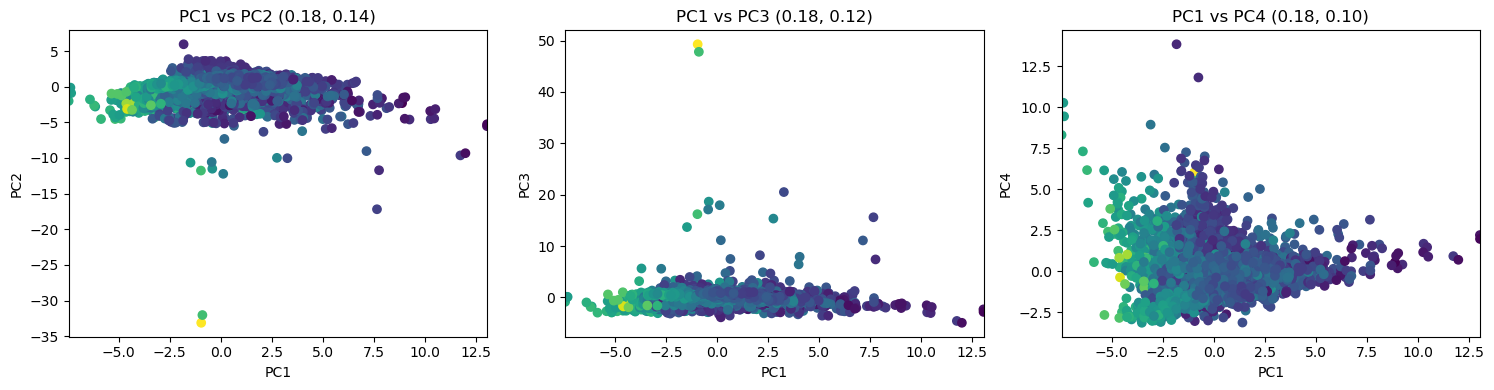

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PC1 vs PC2
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],c=y, cmap="viridis")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PC1 vs PC2")

# PC1 vs PC3
axes[1].scatter(X_pca[:, 0], X_pca[:, 2],c=y, cmap="viridis")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC3")
axes[1].set_title("PC1 vs PC3")

# PC1 vs PC4
axes[2].scatter(X_pca[:, 0], X_pca[:, 3],c=y, cmap="viridis")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC4")
axes[2].set_title("PC1 vs PC4")

ev = pca.explained_variance_ratio_

axes[0].set_title(f"PC1 vs PC2 ({ev[0]:.2f}, {ev[1]:.2f})")
axes[1].set_title(f"PC1 vs PC3 ({ev[0]:.2f}, {ev[2]:.2f})")
axes[2].set_title(f"PC1 vs PC4 ({ev[0]:.2f}, {ev[3]:.2f})")

for ax in axes:
    ax.set_xlim(X_pca[:, 0].min(), X_pca[:, 0].max())

plt.tight_layout()
plt.show()

### Check which PC correlates with the target

In [29]:
from scipy.stats import pearsonr

results = []

for i in range(X_pca.shape[1]):
    r, p = pearsonr(X_pca[:, i], y)
    results.append((f"PC{i+1}", r, p))

corr_df = pd.DataFrame(results, columns=["PC", "r", "p_value"])
corr_df = corr_df.sort_values("r", key=abs, ascending=False)

print(corr_df)

      PC         r        p_value
0    PC1 -0.528903   0.000000e+00
4    PC5 -0.353439  2.662481e-143
11  PC12 -0.240479   4.935842e-65
9   PC10  0.199990   3.971261e-45
1    PC2 -0.183372   4.256016e-38
3    PC4 -0.158566   8.530751e-29
20  PC21 -0.139301   1.554736e-22
7    PC8  0.117535   1.879528e-16
6    PC7  0.107055   6.823268e-14
5    PC6 -0.104555   2.567199e-13
8    PC9  0.091268   1.753572e-10
14  PC15 -0.078209   4.619650e-08
17  PC18  0.054030   1.615109e-04
13  PC14 -0.045475   1.500071e-03
18  PC19  0.040426   4.774825e-03
10  PC11 -0.038486   7.223851e-03
12  PC13 -0.027118   5.842678e-02
16  PC17 -0.023525   1.006550e-01
2    PC3 -0.018713   1.916199e-01
15  PC16 -0.008673   5.450888e-01
19  PC20 -0.000286   9.840799e-01


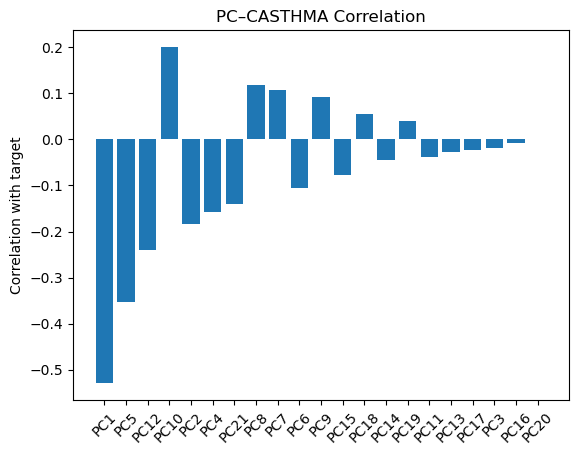

In [30]:
plt.figure()
plt.bar(corr_df["PC"], corr_df["r"])
plt.xticks(rotation=45)
plt.ylabel("Correlation with target")
plt.title("PC–CASTHMA Correlation")
plt.show()

### Check loadings for components

In [31]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X_subset.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

def top_features_per_pc(loadings, top_n=10):
    top_dict = {}

    for pc in loadings.index:
        sorted_features = loadings.loc[pc].abs().sort_values(ascending=False)
        top_features = sorted_features.head(top_n).index.tolist()
        top_dict[pc] = top_features

    return top_dict

top_features = top_features_per_pc(loadings, top_n=10)
print(top_features)

{'PC1': ['median_income', 'OBESITY', 'CSMOKING', 'DIABETES', 'pct_asian', 'rural_binary', 'population', 'pct_black', 'cropland_diversity', 'county_crop_concentration'], 'PC2': ['pct_white', 'log_op_per_cropland_acre', 'pct_black', 'log_carbamate_per_cropland_acre', 'log_pyrethroid_per_cropland_acre', 'pct_hispanic', 'median_age', 'DIABETES', 'pct_cropland', 'population'], 'PC3': ['log_pyrethroid_per_cropland_acre', 'log_carbamate_per_cropland_acre', 'log_op_per_cropland_acre', 'pct_white', 'pct_black', 'median_age', 'cropland_diversity', 'pct_hispanic', 'OBESITY', 'county_crop_concentration'], 'PC4': ['log_op_per_capita', 'log_pyrethroid_per_capita', 'pct_cropland', 'county_crop_concentration', 'log_carbamate_per_capita', 'cropland_diversity', 'pct_black', 'pct_white', 'median_age', 'YEAR'], 'PC5': ['pct_hispanic', 'county_crop_concentration', 'pct_black', 'rural_binary', 'CSMOKING', 'log_op_per_capita', 'pct_white', 'log_carbamate_per_capita', 'log_pyrethroid_per_capita', 'OBESITY'], 

In [32]:
pc1 = loadings.loc["PC1"].sort_values(key=abs, ascending=False)
print(pc1.head(10))

median_income                0.432521
OBESITY                     -0.397430
CSMOKING                    -0.396423
DIABETES                    -0.387096
pct_asian                    0.339529
rural_binary                -0.262208
population                   0.241204
pct_black                   -0.158243
cropland_diversity           0.151203
county_crop_concentration   -0.121557
Name: PC1, dtype: float64


In [33]:
pc4 = loadings.loc["PC4"].sort_values(key=abs, ascending=False)
print(pc4.head(10))

log_op_per_capita            0.480180
log_pyrethroid_per_capita    0.463057
pct_cropland                 0.459352
county_crop_concentration   -0.338342
log_carbamate_per_capita     0.248525
cropland_diversity           0.198641
pct_black                    0.161539
pct_white                   -0.151537
median_age                  -0.140580
YEAR                        -0.120703
Name: PC4, dtype: float64


In [34]:
pc9 = loadings.loc["PC9"].sort_values(key=abs, ascending=False)
print(pc9.head(10))

log_carbamate_per_capita     0.697433
median_age                  -0.370902
rural_binary                -0.310809
YEAR                        -0.298824
cropland_diversity          -0.292076
CSMOKING                     0.187177
county_crop_concentration    0.106192
pct_black                   -0.096948
log_pyrethroid_per_capita   -0.091324
log_op_per_capita           -0.089613
Name: PC9, dtype: float64


In [35]:
pc11 = loadings.loc["PC11"].sort_values(key=abs, ascending=False)
print(pc11.head(10))

rural_binary                 0.686792
cropland_diversity          -0.304249
pct_black                    0.277909
OBESITY                     -0.262838
population                  -0.209969
county_crop_concentration   -0.192490
median_age                  -0.190477
log_op_per_capita           -0.168957
CSMOKING                    -0.164807
pct_asian                    0.156785
Name: PC11, dtype: float64


## COPD

[0.18606555 0.13577809 0.11505837 0.09715815 0.07251799 0.05903703
 0.05030488 0.04402869 0.03986144 0.03588756 0.02887935 0.02550698
 0.01986593 0.01954061 0.01614481 0.01397007 0.01295075 0.00946291
 0.00911719 0.00632363 0.00254   ]
0.9999999999999999


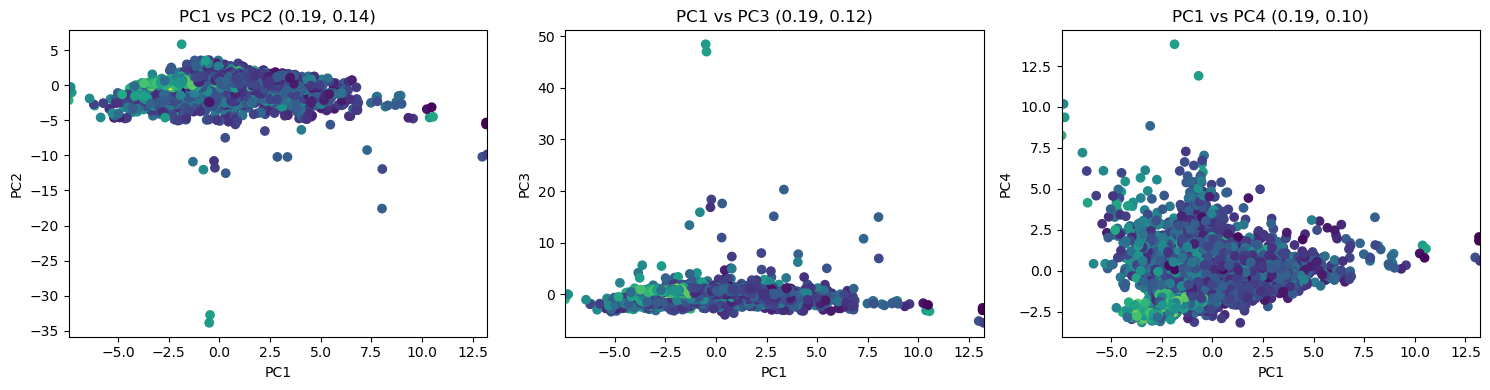

In [36]:
X_subset = train_copd[FEATURES_COMPONENTS].fillna(0)
y = train_asthma['COPD']
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_subset)

# PCA
pca = PCA()  # for visualization
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PC1 vs PC2
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],c=y, cmap="viridis")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PC1 vs PC2")

# PC1 vs PC3
axes[1].scatter(X_pca[:, 0], X_pca[:, 2],c=y, cmap="viridis")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC3")
axes[1].set_title("PC1 vs PC3")

# PC1 vs PC4
axes[2].scatter(X_pca[:, 0], X_pca[:, 3],c=y, cmap="viridis")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC4")
axes[2].set_title("PC1 vs PC4")

ev = pca.explained_variance_ratio_

axes[0].set_title(f"PC1 vs PC2 ({ev[0]:.2f}, {ev[1]:.2f})")
axes[1].set_title(f"PC1 vs PC3 ({ev[0]:.2f}, {ev[2]:.2f})")
axes[2].set_title(f"PC1 vs PC4 ({ev[0]:.2f}, {ev[3]:.2f})")

for ax in axes:
    ax.set_xlim(X_pca[:, 0].min(), X_pca[:, 0].max())

plt.tight_layout()
plt.show()

      PC         r       p_value
0    PC1 -0.279914  2.206445e-88
5    PC6 -0.231014  5.089978e-60
8    PC9  0.210738  5.048283e-50
4    PC5 -0.205206  1.809673e-47
3    PC4 -0.129249  1.349597e-19
20  PC21  0.112376  3.662903e-15
9   PC10  0.102244  8.504628e-13
14  PC15 -0.072619  3.902826e-07
1    PC2 -0.061519  1.734851e-05
13  PC14  0.059395  3.355051e-05
17  PC18  0.056966  6.950389e-05
10  PC11 -0.054981  1.234557e-04
18  PC19  0.049907  4.932280e-04
15  PC16  0.048031  7.986688e-04
6    PC7 -0.044400  1.938235e-03
16  PC17 -0.033365  1.987638e-02
19  PC20  0.032185  2.468551e-02
12  PC13 -0.024081  9.286100e-02
7    PC8  0.010064  4.825377e-01
11  PC12  0.008619  5.475905e-01
2    PC3 -0.000596  9.668077e-01


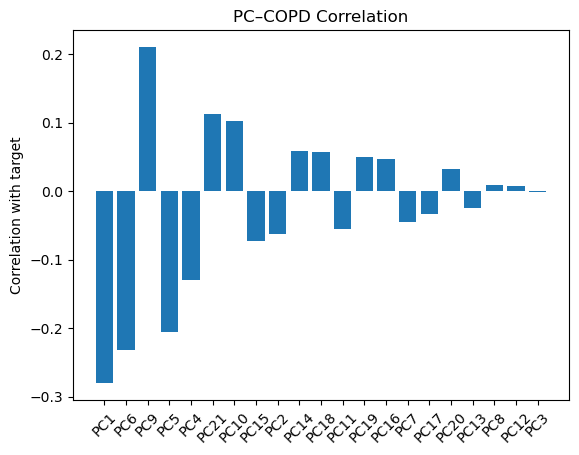

In [37]:
results = []

for i in range(X_pca.shape[1]):
    r, p = pearsonr(X_pca[:, i], y)
    results.append((f"PC{i+1}", r, p))

corr_df = pd.DataFrame(results, columns=["PC", "r", "p_value"])
corr_df = corr_df.sort_values("r", key=abs, ascending=False)

print(corr_df)

plt.figure()
plt.bar(corr_df["PC"], corr_df["r"])
plt.xticks(rotation=45)
plt.ylabel("Correlation with target")
plt.title("PC–COPD Correlation")
plt.show()

In [38]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X_subset.columns,
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)

def top_features_per_pc(loadings, top_n=10):
    top_dict = {}

    for pc in loadings.index:
        sorted_features = loadings.loc[pc].abs().sort_values(ascending=False)
        top_features = sorted_features.head(top_n).index.tolist()
        top_dict[pc] = top_features

    return top_dict

top_features = top_features_per_pc(loadings, top_n=10)
# print(top_features)

In [39]:
pc4 = loadings.loc["PC4"].sort_values(key=abs, ascending=False)
print(pc4.head(10))

log_op_per_capita            0.477280
pct_cropland                 0.475419
log_pyrethroid_per_capita    0.455353
county_crop_concentration   -0.352350
log_carbamate_per_capita     0.246694
cropland_diversity           0.186267
pct_black                    0.149585
pct_white                   -0.143627
median_age                  -0.141794
YEAR                        -0.112438
Name: PC4, dtype: float64


In [40]:
pc1 = loadings.loc["PC1"].sort_values(key=abs, ascending=False)
print(pc1.head(10))

median_income                0.428215
CSMOKING                    -0.396383
OBESITY                     -0.395830
DIABETES                    -0.382162
pct_asian                    0.339475
rural_binary                -0.257112
population                   0.252254
pct_black                   -0.169830
cropland_diversity           0.157636
county_crop_concentration   -0.108579
Name: PC1, dtype: float64


In [41]:
pc7 = loadings.loc["PC7"].sort_values(key=abs, ascending=False)
print(pc7.head(10))

median_age                  0.548369
log_carbamate_per_capita    0.507067
cropland_diversity          0.382284
pct_cropland               -0.347048
pct_black                   0.200641
pct_hispanic               -0.175676
OBESITY                    -0.162117
DIABETES                    0.124905
population                  0.117870
log_op_per_capita           0.095063
Name: PC7, dtype: float64


In [42]:
pc17 = loadings.loc["PC17"].sort_values(key=abs, ascending=False)
print(pc17.head(10))

log_op_per_cropland_acre            0.695172
log_carbamate_per_cropland_acre    -0.519978
log_op_per_capita                  -0.348975
log_pyrethroid_per_capita           0.203781
OBESITY                             0.145156
log_pyrethroid_per_cropland_acre   -0.121304
CSMOKING                           -0.105347
log_carbamate_per_capita            0.105271
county_crop_concentration           0.073256
pct_cropland                        0.072780
Name: PC17, dtype: float64
